<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Fri Oct  2 18:00:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 615.71.08              KMD Version: 616.92        CUDA UMD Version: 13.4     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8              3W /   95W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [86]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code

device: torch.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(device)

class Env:
    RANDOM_SEED: int = 42
    BATCH_SIZE: int = 32
    LEARNING_RATE: float = 0.1
    EPOCHS: int = 5

2.11.0+cu128
cuda


## 1. What are 3 areas in industry where computer vision is currently being used?

1. Face Id
2. Turn Signals
3. Auto Drive
4. Cameras

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Without Searching, overfitting is when the model perform very well on the train data but poorly on the test data 
meaning insted of learning general patterns it start to learn spicific patterns that are in the train data 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Use larger training set , the more data you give the more likely for the model to find general patterns.
2. Regularization: we add a panelty for large weghts into the loss so our forula go from Loss = L(y_pred, y_true) -> Loss = L(y_pred, y_true) + lamda * f(W) where lambda > 0 and f incearece when W does
3. Data augmentation , which means to create more data from our data (e.g. rotateing image , clip image , crop image, random eraseing ...) this make our data lose very spicific patterns and force our model to learn more general patterns that remain in most data

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

DONE

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [109]:
from torchvision.transforms import ToTensor
from torchvision import datasets
from pathlib import Path

train_data = datasets.MNIST(
    root = Path() / ".." / "data",
    download= True,
    train = True,
    transform = ToTensor(),
    target_transform = None
)

test_data =  datasets.MNIST(
    root = Path() / ".." / "data",
    download= True,
    train = False,
    transform = ToTensor(),
    target_transform = None
)


## 6. Visualize at least 5 different samples of the MNIST training dataset.

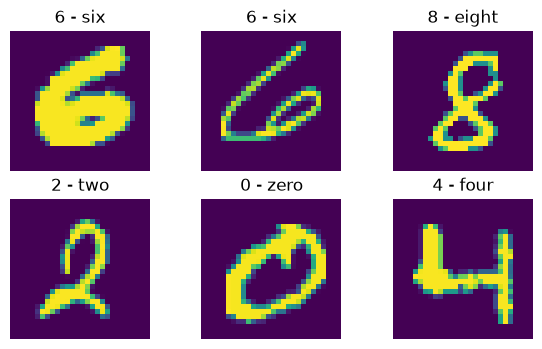

In [110]:
import matplotlib.pyplot as plt

torch.manual_seed(42)


classes = train_data.classes

idx = 0
fig = plt.figure(figsize=(7, 4))
rows, cols = 2, 3
for i in range(1, 7):
    random_idx = torch.randint(low = 0 , high = len(train_data), size=(1,))
    fig.add_subplot(rows, cols, i)
    plt.imshow(train_data.data[random_idx].squeeze(dim=0))
    plt.title(classes[train_data.targets[random_idx]])
    plt.axis(False)



## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [111]:
from torch.utils.data import DataLoader

train_dataloader =  DataLoader(
    dataset = train_data,
    batch_size = Env.BATCH_SIZE,
    shuffle = True,
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = Env.BATCH_SIZE,
    shuffle = False,
)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [112]:
from torch import nn

class ModelV2(nn.Module):

    def __init__(self, 
                 input_channels: int,
                 hidden_layer: int,
                 output_shape: int):

            super().__init__()

            self.conv1 = nn.Sequential(
                nn.Conv2d( 
                        in_channels = input_channels,
                        out_channels = hidden_layer,
                        kernel_size = 2,
                        stride = 1,
                        padding = 0
                    ),

                nn.ReLU(),

                nn.Conv2d( 
                        in_channels = hidden_layer,
                        out_channels = hidden_layer,
                        kernel_size = 2,
                        stride = 1,
                        padding = 0
                    ),

                nn.ReLU(),

                nn.MaxPool2d(
                      kernel_size = 2
                )
            )

            self.conv2 = nn.Sequential(
                nn.Conv2d( 
                        in_channels = hidden_layer,
                        out_channels = hidden_layer,
                        kernel_size = 2,
                        stride = 1,
                        padding = 0
                    ),

                nn.ReLU(),

                nn.Conv2d( 
                        in_channels = hidden_layer,
                        out_channels = hidden_layer,
                        kernel_size = 2,
                        stride = 1,
                        padding = 0
                    ),

                nn.ReLU(),

                nn.MaxPool2d(
                      kernel_size = 2
                )
            )

            self.classifier = nn.Sequential(
                  nn.Flatten(),
                  nn.Linear(in_features = hidden_layer * 5 * 5, out_features = output_shape),
            )
            
    def forward(self, x: torch.Tensor) -> torch.Tensor:
          x = self.conv1(x)
          x = self.conv2(x)
          x = self.classifier(x)
          return x

model = ModelV2(
      input_channels = 1,
      hidden_layer = 10,
      output_shape = len(classes)
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [117]:
import pandas as pd
results: pd.DataFrame = pd.DataFrame(index = ['cpu', 'cuda'], data = {'train_time': [0., 0.], 'test_time': [0., 0.]})

In [118]:
results

,train_time,test_time
cpu,0.0,0.0
cuda,0.0,0.0


In [119]:
from tqdm.auto import tqdm
from torchmetrics import Metric
from timeit import default_timer as timer

def train_step (
        model: nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: nn.Module,
        acc_fn: Metric,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        results: pd.DataFrame
):

        model = model.to(device)
        acc_fn = acc_fn.to(device)

        loss_fn = loss_fn.to(device)

        model.train()

        start_time = timer()
        loss = torch.tensor(0.0, device=device)

        acc_fn.reset()

        for X, y in data_loader:
                X = X.to(device)

                y = y.to(device)

                y_logits = model(X)

                batch_loss = loss_fn(y_logits, y)

                acc_fn.update(y_logits.argmax(dim=1), y)

                optimizer.zero_grad()

                batch_loss.backward()

                optimizer.step()

                loss += batch_loss.detach()

        loss = (loss / len(data_loader)).item()

        acc = acc_fn.compute().item()

        print(f"Train Loss: {loss: .2f} | Train Accuracy: {acc: .2%}")
        end_time = timer()
                        
        results.loc['cpu', 'train_time'] += end_time - start_time


def test_step (
        model: nn.Module,
        data_loader: torch.utils.data.DataLoader,
        loss_fn: nn.Module,
        acc_fn: Metric,
        device: torch.device,
        results: pd.DataFrame
):

        model = model.to(device)
        acc_fn = acc_fn.to(device)

        loss_fn = loss_fn.to(device)

        model.eval()

        start_time = timer()
        loss = torch.tensor(0.0, device=device)

        acc_fn.reset()


        for X, y in data_loader:
                X = X.to(device)

                y = y.to(device)

                y_logits = model(X)

                batch_loss = loss_fn(y_logits, y)

                acc_fn.update(y_logits.argmax(dim=1), y)



                loss += batch_loss.detach()

        loss = (loss / len(data_loader)).item()

        acc = acc_fn.compute().item()

        print(f"Test Loss: {loss: .2f} | Test Accuracy: {acc: .2%}")
        end_time = timer()
                        
        results.loc['cpu', 'test_time'] += end_time - start_time
        





In [120]:
from torchmetrics import Accuracy
model_on_cuda = ModelV2(
    input_channels=1,
    hidden_layer=10,
    output_shape= len(classes)
).to(torch.device('cuda'))

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params = model_on_cuda.parameters(),
    lr = Env.LEARNING_RATE
)

acc_fn = Accuracy(task = 'multiclass', num_classes = len(classes))



for epoch in tqdm(range(Env.EPOCHS)):

    train_step(
        model = model_on_cuda,
        data_loader = train_dataloader,
        loss_fn = loss_fn,
        acc_fn = acc_fn,
        optimizer = optimizer,
        device = torch.device('cuda'),
        results = results
        
    )

    test_step(

        model = model_on_cuda,
        data_loader = train_dataloader,
        loss_fn = loss_fn,
        acc_fn = acc_fn,
        device = torch.device('cuda'),
        results = results
    )

  0%|          | 0/5 [00:00<?, ?it/s]

Train Loss:  2.31 | Train Accuracy:  10.46%


 20%|██        | 1/5 [00:42<02:49, 42.43s/it]

Test Loss:  2.31 | Test Accuracy:  9.86%
Train Loss:  2.31 | Train Accuracy:  10.21%


 40%|████      | 2/5 [01:19<01:58, 39.42s/it]

...

Test Loss:  2.31 | Test Accuracy:  11.24%
Train Loss:  2.31 | Train Accuracy:  10.39%


 80%|████████  | 4/5 [02:33<00:37, 37.55s/it]

Test Loss:  2.31 | Test Accuracy:  10.44%
Train Loss:  2.31 | Train Accuracy:  10.10%


100%|██████████| 5/5 [03:14<00:00, 38.90s/it]

Test Loss:  2.31 | Test Accuracy:  9.86%


In [ ]:

model_on_cpu = ModelV2(
    input_channels=1,
    hidden_layer=10,
    output_shape= len(classes)
).to(torch.device('cpu'))

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params = model_on_cpu.parameters(),
    lr = Env.LEARNING_RATE
)

acc_fn = Accuracy(task = 'multiclass', num_classes = len(classes))



for epoch in tqdm(range(Env.EPOCHS)):

    train_step(
        model = model_on_cuda,
        data_loader = train_dataloader,
        loss_fn = loss_fn,
        acc_fn = acc_fn,
        optimizer = optimizer,
        device = torch.device('cpu'),
        results = results
        
    )

    test_step(
        model = model_on_cuda,
        data_loader = train_dataloader,
        loss_fn = loss_fn,
        acc_fn = acc_fn,
        device = torch.device('cpu'),
        results = results
    )

  0%|          | 0/5 [00:00<?, ?it/s]

Train Loss:  2.31 | Train Accuracy:  9.86%


 20%|██        | 1/5 [00:25<01:42, 25.64s/it]

Test Loss:  2.31 | Test Accuracy:  9.86%
Train Loss:  2.31 | Train Accuracy:  9.86%


 40%|████      | 2/5 [00:58<01:30, 30.05s/it]

...

Test Loss:  2.31 | Test Accuracy:  9.86%
Train Loss:  2.31 | Train Accuracy:  9.86%


 80%|████████  | 4/5 [01:57<00:29, 29.66s/it]

Test Loss:  2.31 | Test Accuracy:  9.86%
Train Loss:  2.31 | Train Accuracy:  9.86%


100%|██████████| 5/5 [02:26<00:00, 29.37s/it]

Test Loss:  2.31 | Test Accuracy:  9.86%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?